In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


In [ ]:
!nvidia-smi

Wed Jul  8 09:18:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!unzip -q /content/data.zip -d /content/custom_data

In [ ]:
%%writefile train_val_split.py

from pathlib import Path
import random
import os
import shutil  # copies file
import argparse

parser = argparse.ArgumentParser()
parser.add_argument("--datapath", required=True)
parser.add_argument("--train_pct", type=float, default=0.9)

args = parser.parse_args()

data_path = args.datapath
train_percent = args.train_pct

if not os.path.isdir(data_path):
    raise FileNotFoundError(f"Dataset folder not found: {data_path}")

if not 0.01 <= train_percent <= 0.99:
    raise ValueError("train_pct must be between 0.01 and 0.99")

input_image_path = os.path.join(data_path, "images")
input_label_path = os.path.join(data_path, "labels")

train_img_path = os.path.join(data_path, "train", "images")
train_lbl_path = os.path.join(data_path, "train", "labels")

val_img_path = os.path.join(data_path, "validation", "images")
val_lbl_path = os.path.join(data_path, "validation", "labels")

for folder in [
    train_img_path,
    train_lbl_path,
    val_img_path,
    val_lbl_path,
]:
    os.makedirs(folder, exist_ok=True)

image_files = list(Path(input_image_path).glob("*"))

random.shuffle(image_files)

train_count = int(len(image_files) * train_percent)

train_files = image_files[:train_count]
val_files = image_files[train_count:]

def copy_dataset(files, image_dest, label_dest):
    for img_path in files:
        shutil.copy(img_path, image_dest)

        label_file = os.path.join(
            input_label_path,
            img_path.stem + ".txt"
        )

        if os.path.exists(label_file):
            shutil.copy(label_file, label_dest)

copy_dataset(train_files, train_img_path, train_lbl_path)
copy_dataset(val_files, val_img_path, val_lbl_path)

print("Dataset split completed successfully!")

Writing train_val_split.py


In [ ]:
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

Dataset split completed successfully!


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00


In [ ]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):


  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)


  data = {
      'path': '/content/custom_data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }


  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/custom_data
train: train/images
val: validation/images
nc: 3
names:
- data
- legal
- photo


In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=100 imgsz=480

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [ ]:
!yolo detect predict \
model=/content/runs/detect/train/weights/best.pt \
source=/content/custom_data/validation/images \
save=True

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs

image 1/1 /content/custom_data/validation/images/fe836de6-viber_image_2026-07-06_13-33-04-712.jpg: 352x480 1 data, 1 legal, 1 photo, 79.0ms
Speed: 2.3ms preprocess, 79.0ms inference, 23.9ms postprocess per image at shape (1, 3, 352, 480)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


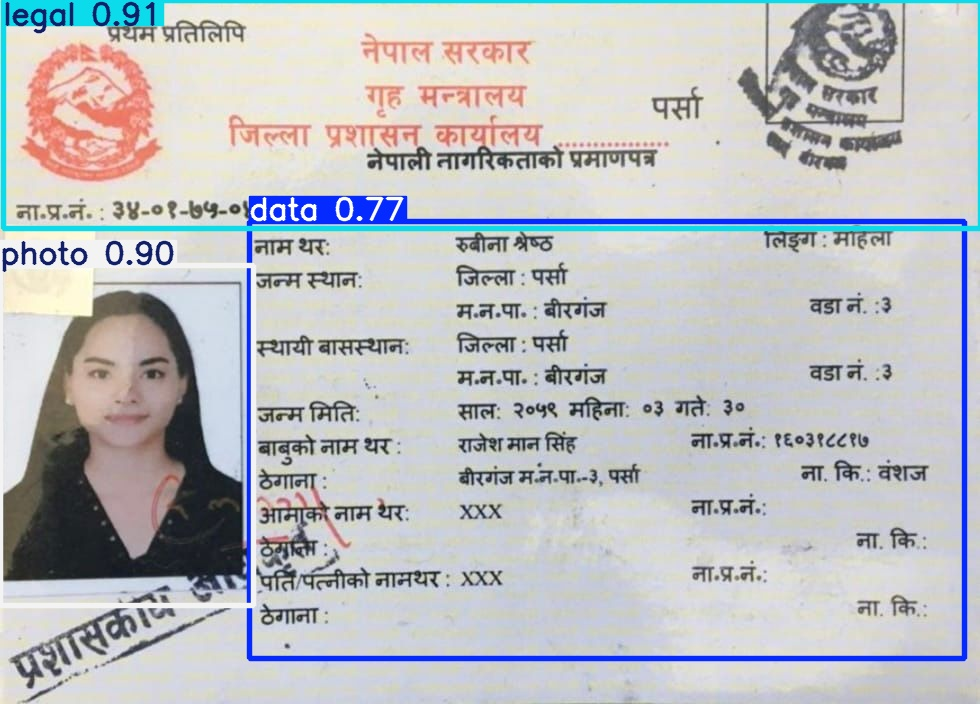

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:5]:
  display(Image(filename=image_path, height=400))
  print('\n')



results.png


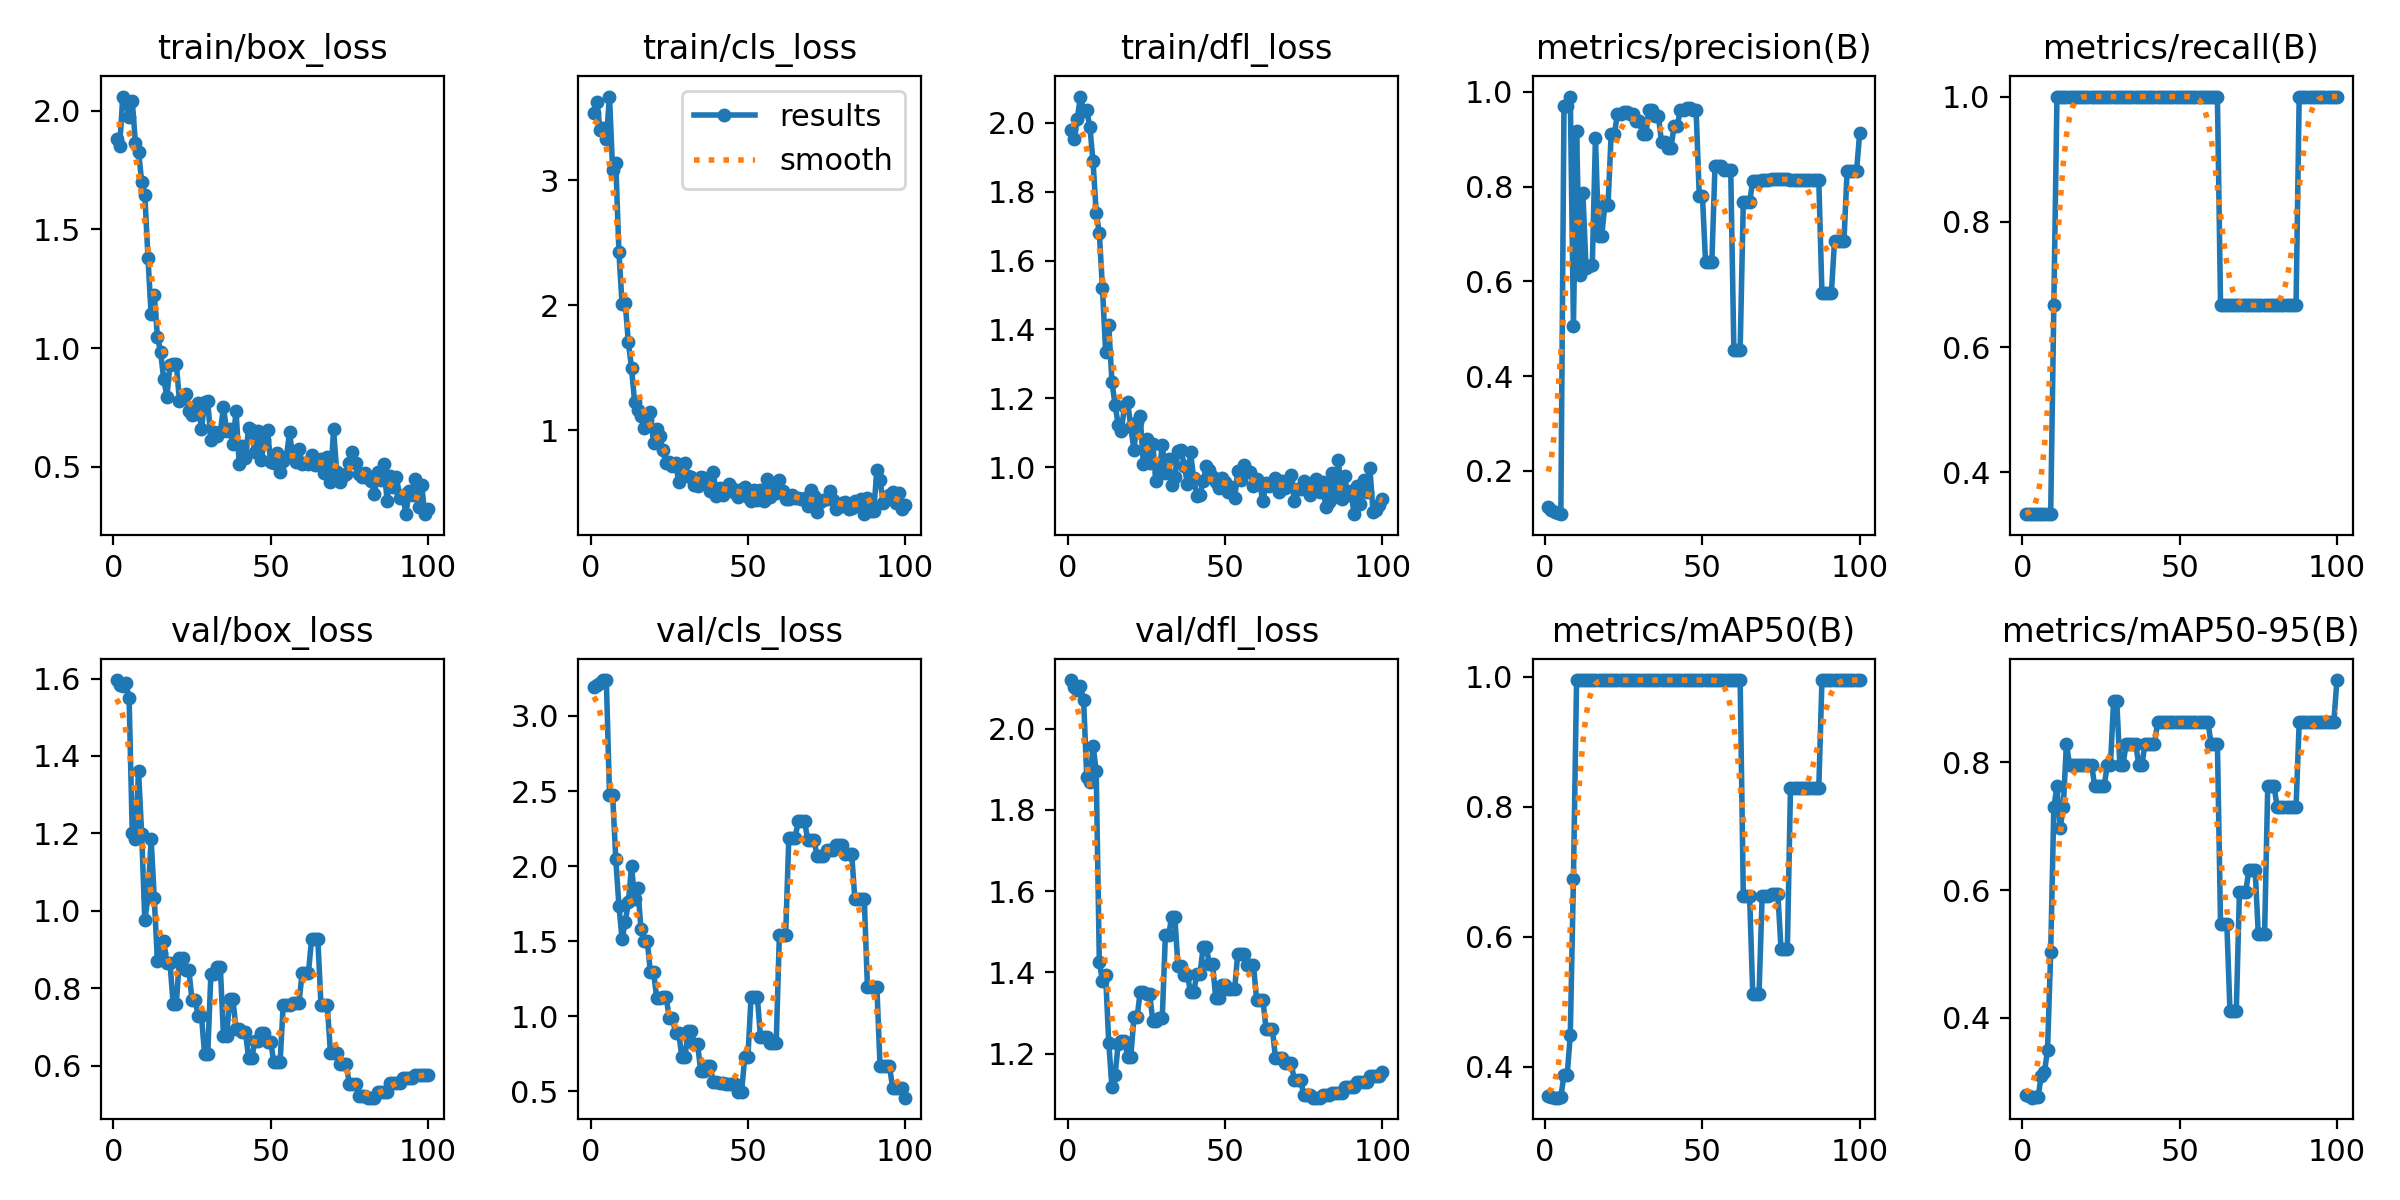


confusion_matrix.png


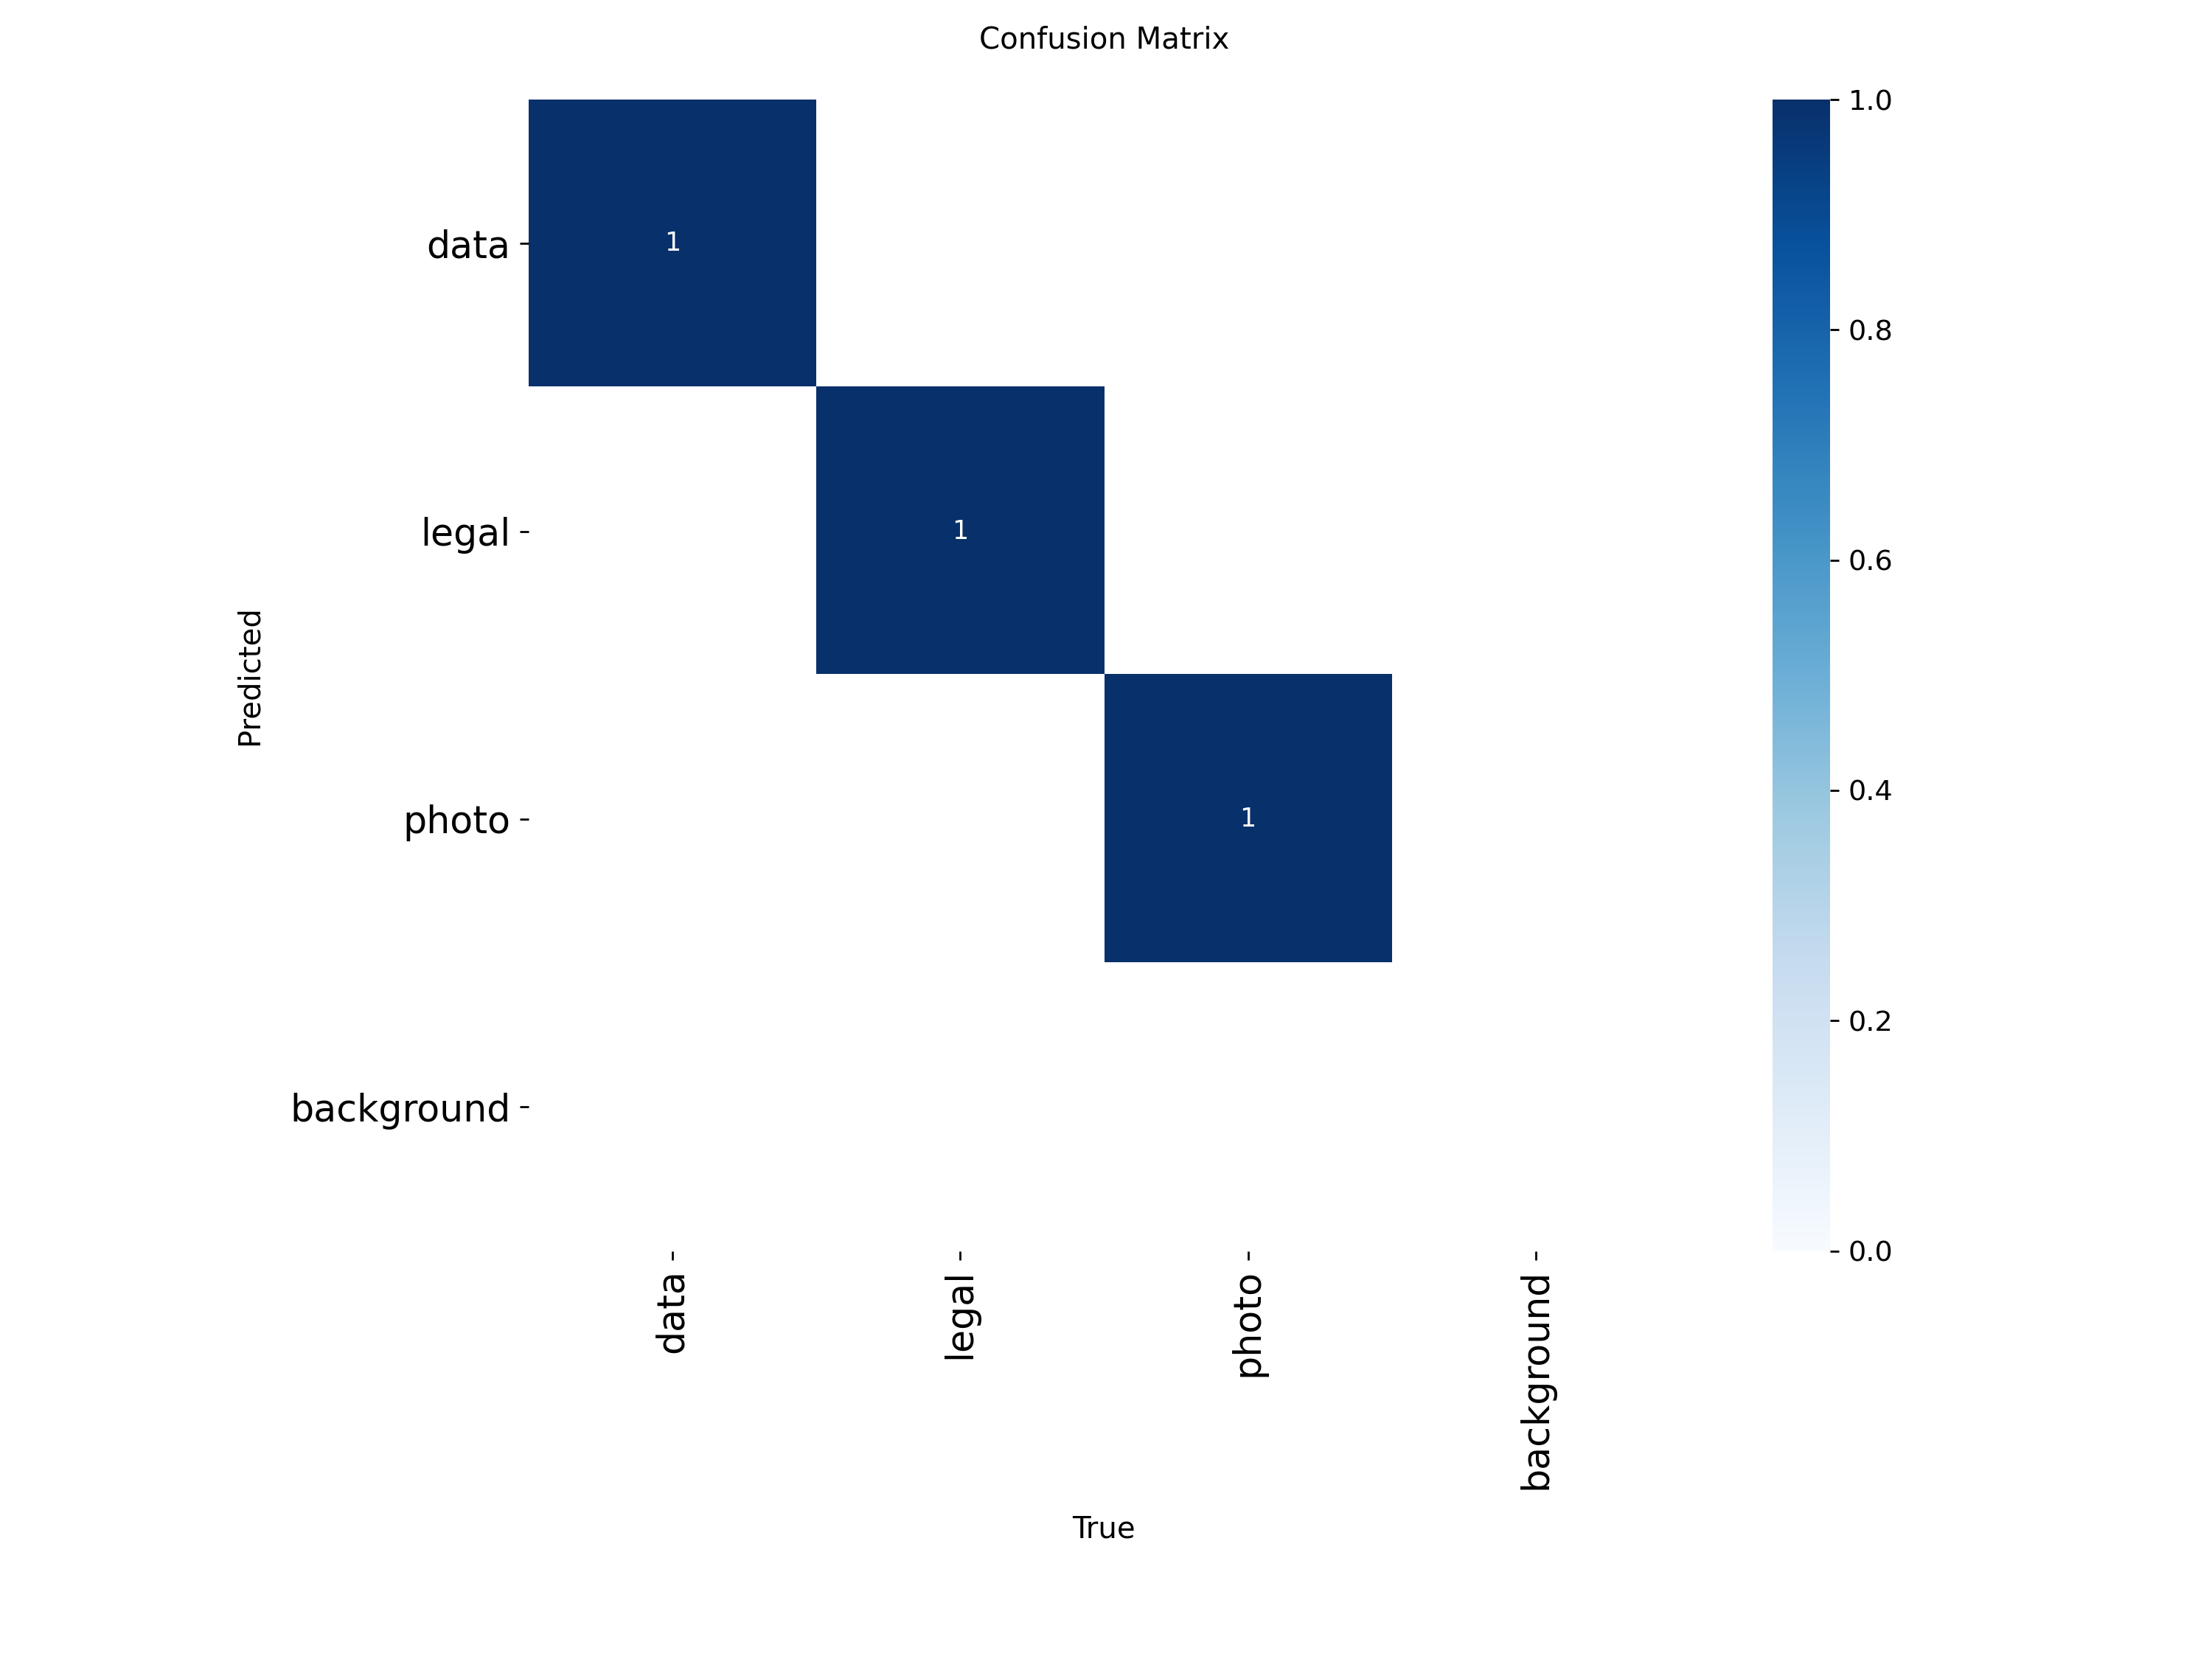


confusion_matrix_normalized.png


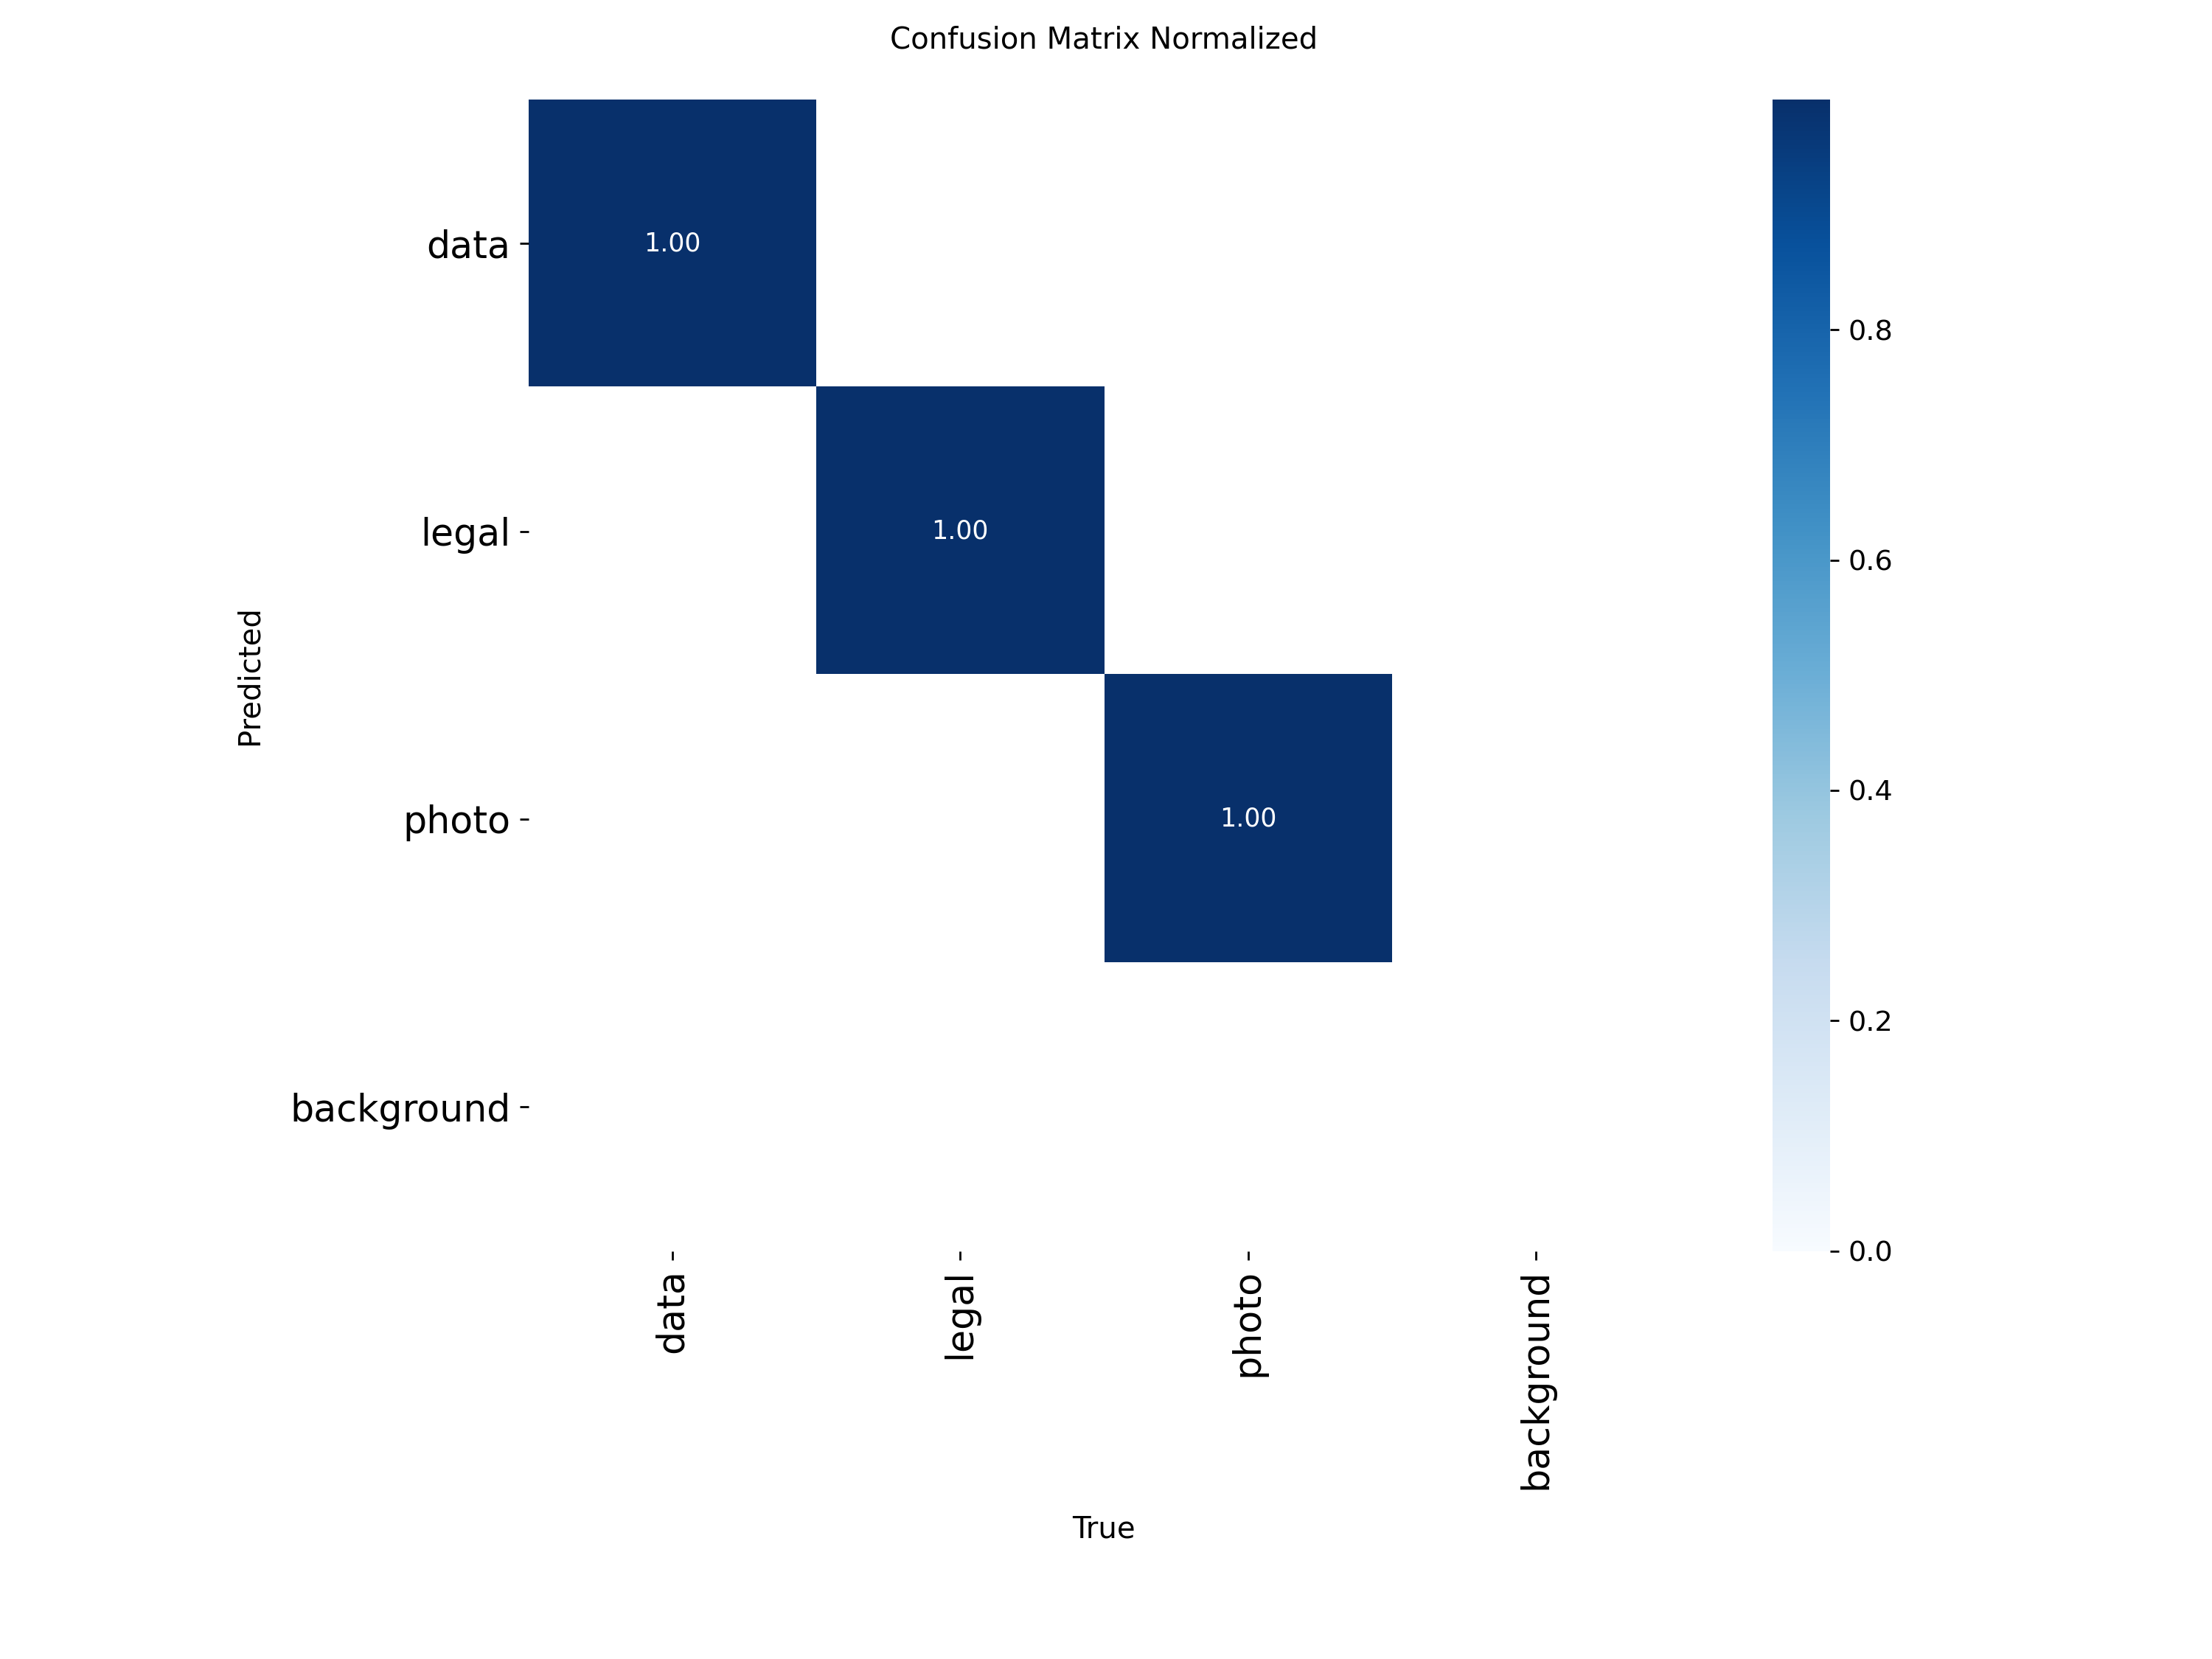

In [ ]:
from IPython.display import display, Image
import os

train_dir = "/content/runs/detect/train"

graphs = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]

for graph in graphs:
    graph_path = os.path.join(train_dir, graph)
    if os.path.exists(graph_path):
        print(f"\n{graph}")
        display(Image(filename=graph_path, width=800))

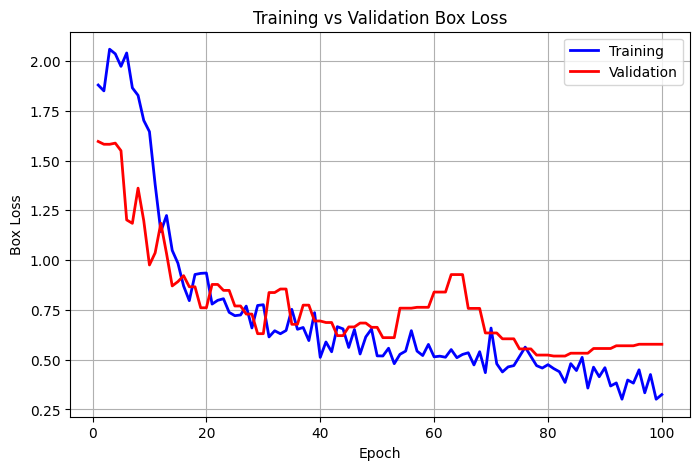

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/runs/detect/train/results.csv")

results.columns = results.columns.str.strip()

plt.figure(figsize=(8,5))

plt.plot(results["epoch"], results["train/box_loss"], "b-", linewidth=2, label="Training")
plt.plot(results["epoch"], results["val/box_loss"], "r-", linewidth=2, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Training vs Validation Box Loss")
plt.legend()
plt.grid(True)

plt.show()

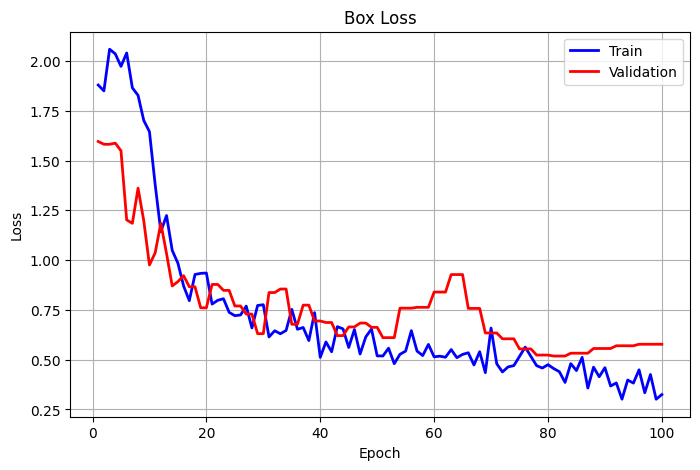

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("/content/runs/detect/train/results.csv")
results.columns = results.columns.str.strip()

plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/box_loss"], "b-", linewidth=2, label="Train")
plt.plot(results["epoch"], results["val/box_loss"], "r-", linewidth=2, label="Validation")
plt.title("Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

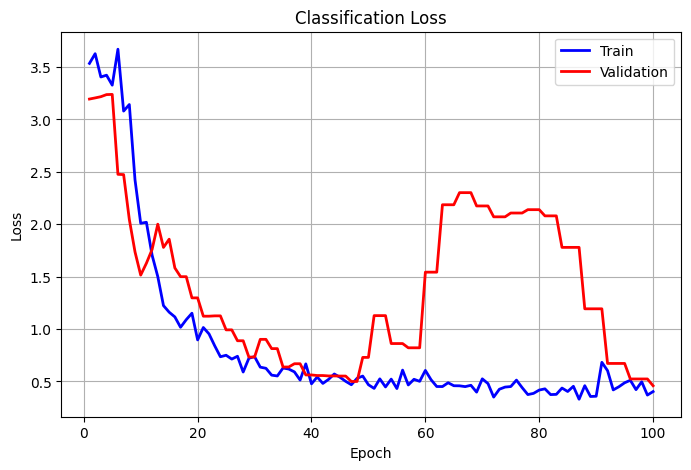

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/cls_loss"], "b-", linewidth=2, label="Train")
plt.plot(results["epoch"], results["val/cls_loss"], "r-", linewidth=2, label="Validation")
plt.title("Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

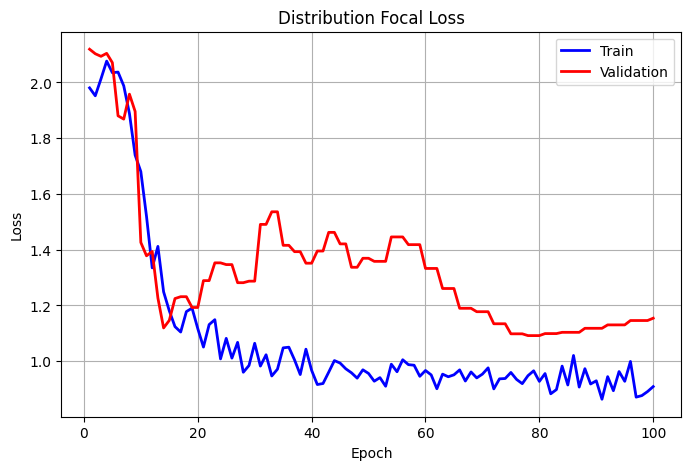

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results["epoch"], results["train/dfl_loss"], "b-", linewidth=2, label="Train")
plt.plot(results["epoch"], results["val/dfl_loss"], "r-", linewidth=2, label="Validation")
plt.title("Distribution Focal Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


BoxF1_curve.png


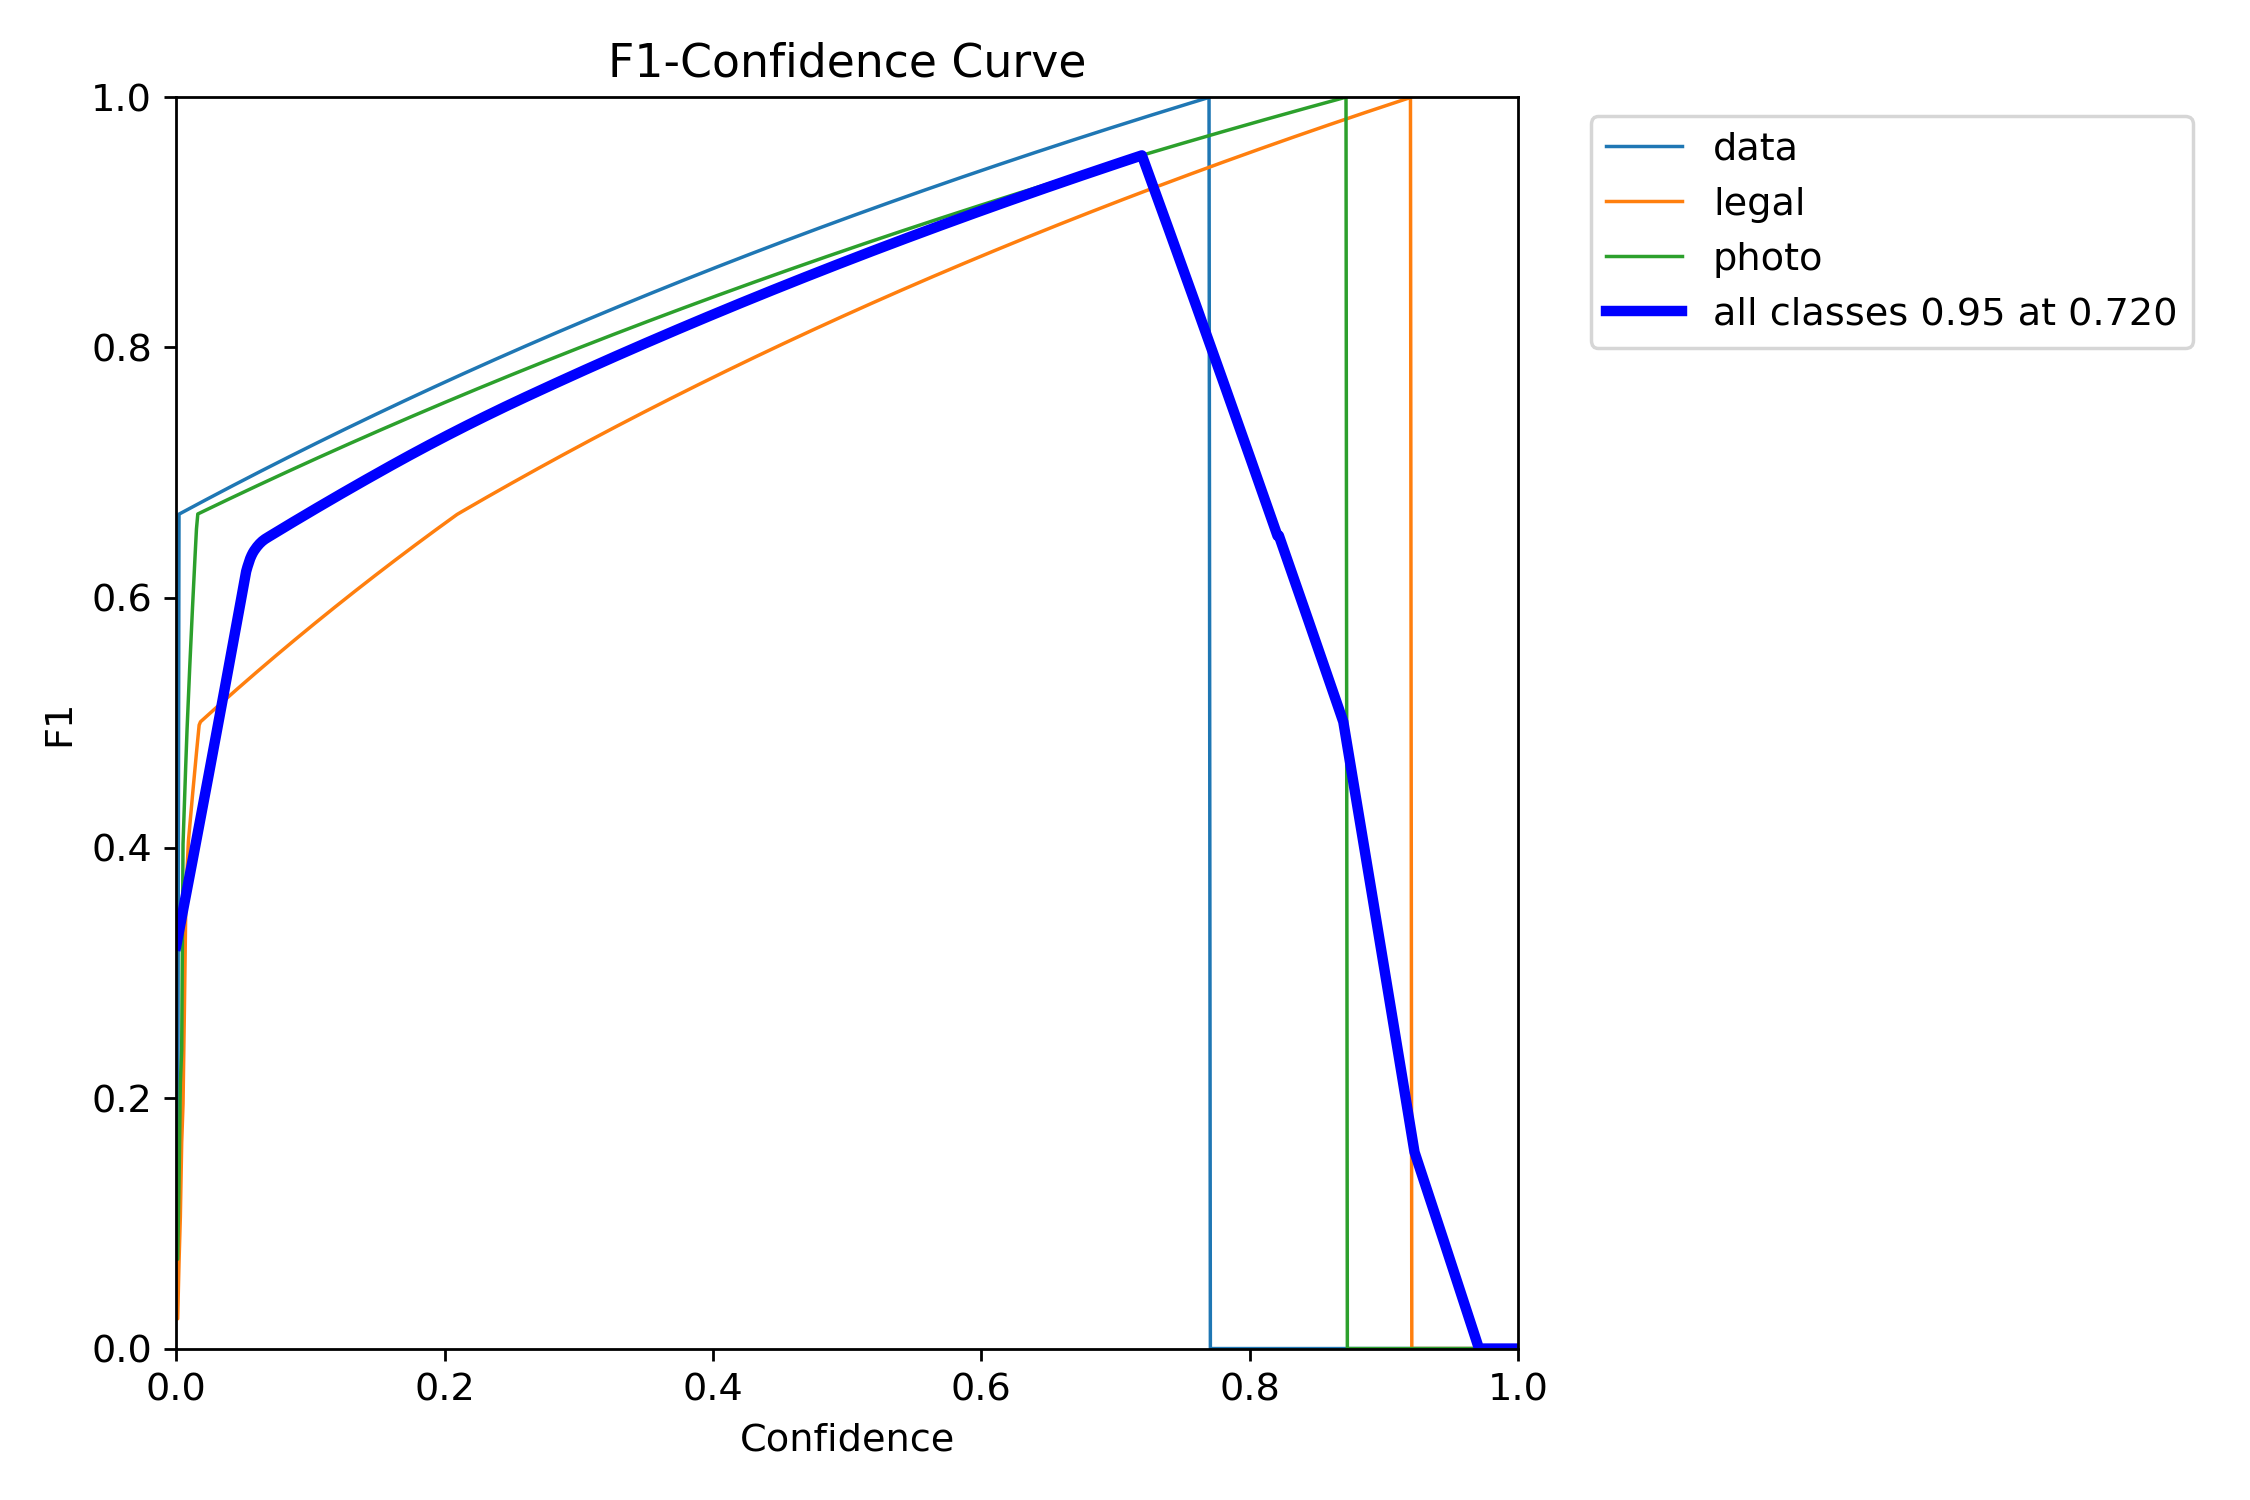


BoxP_curve.png


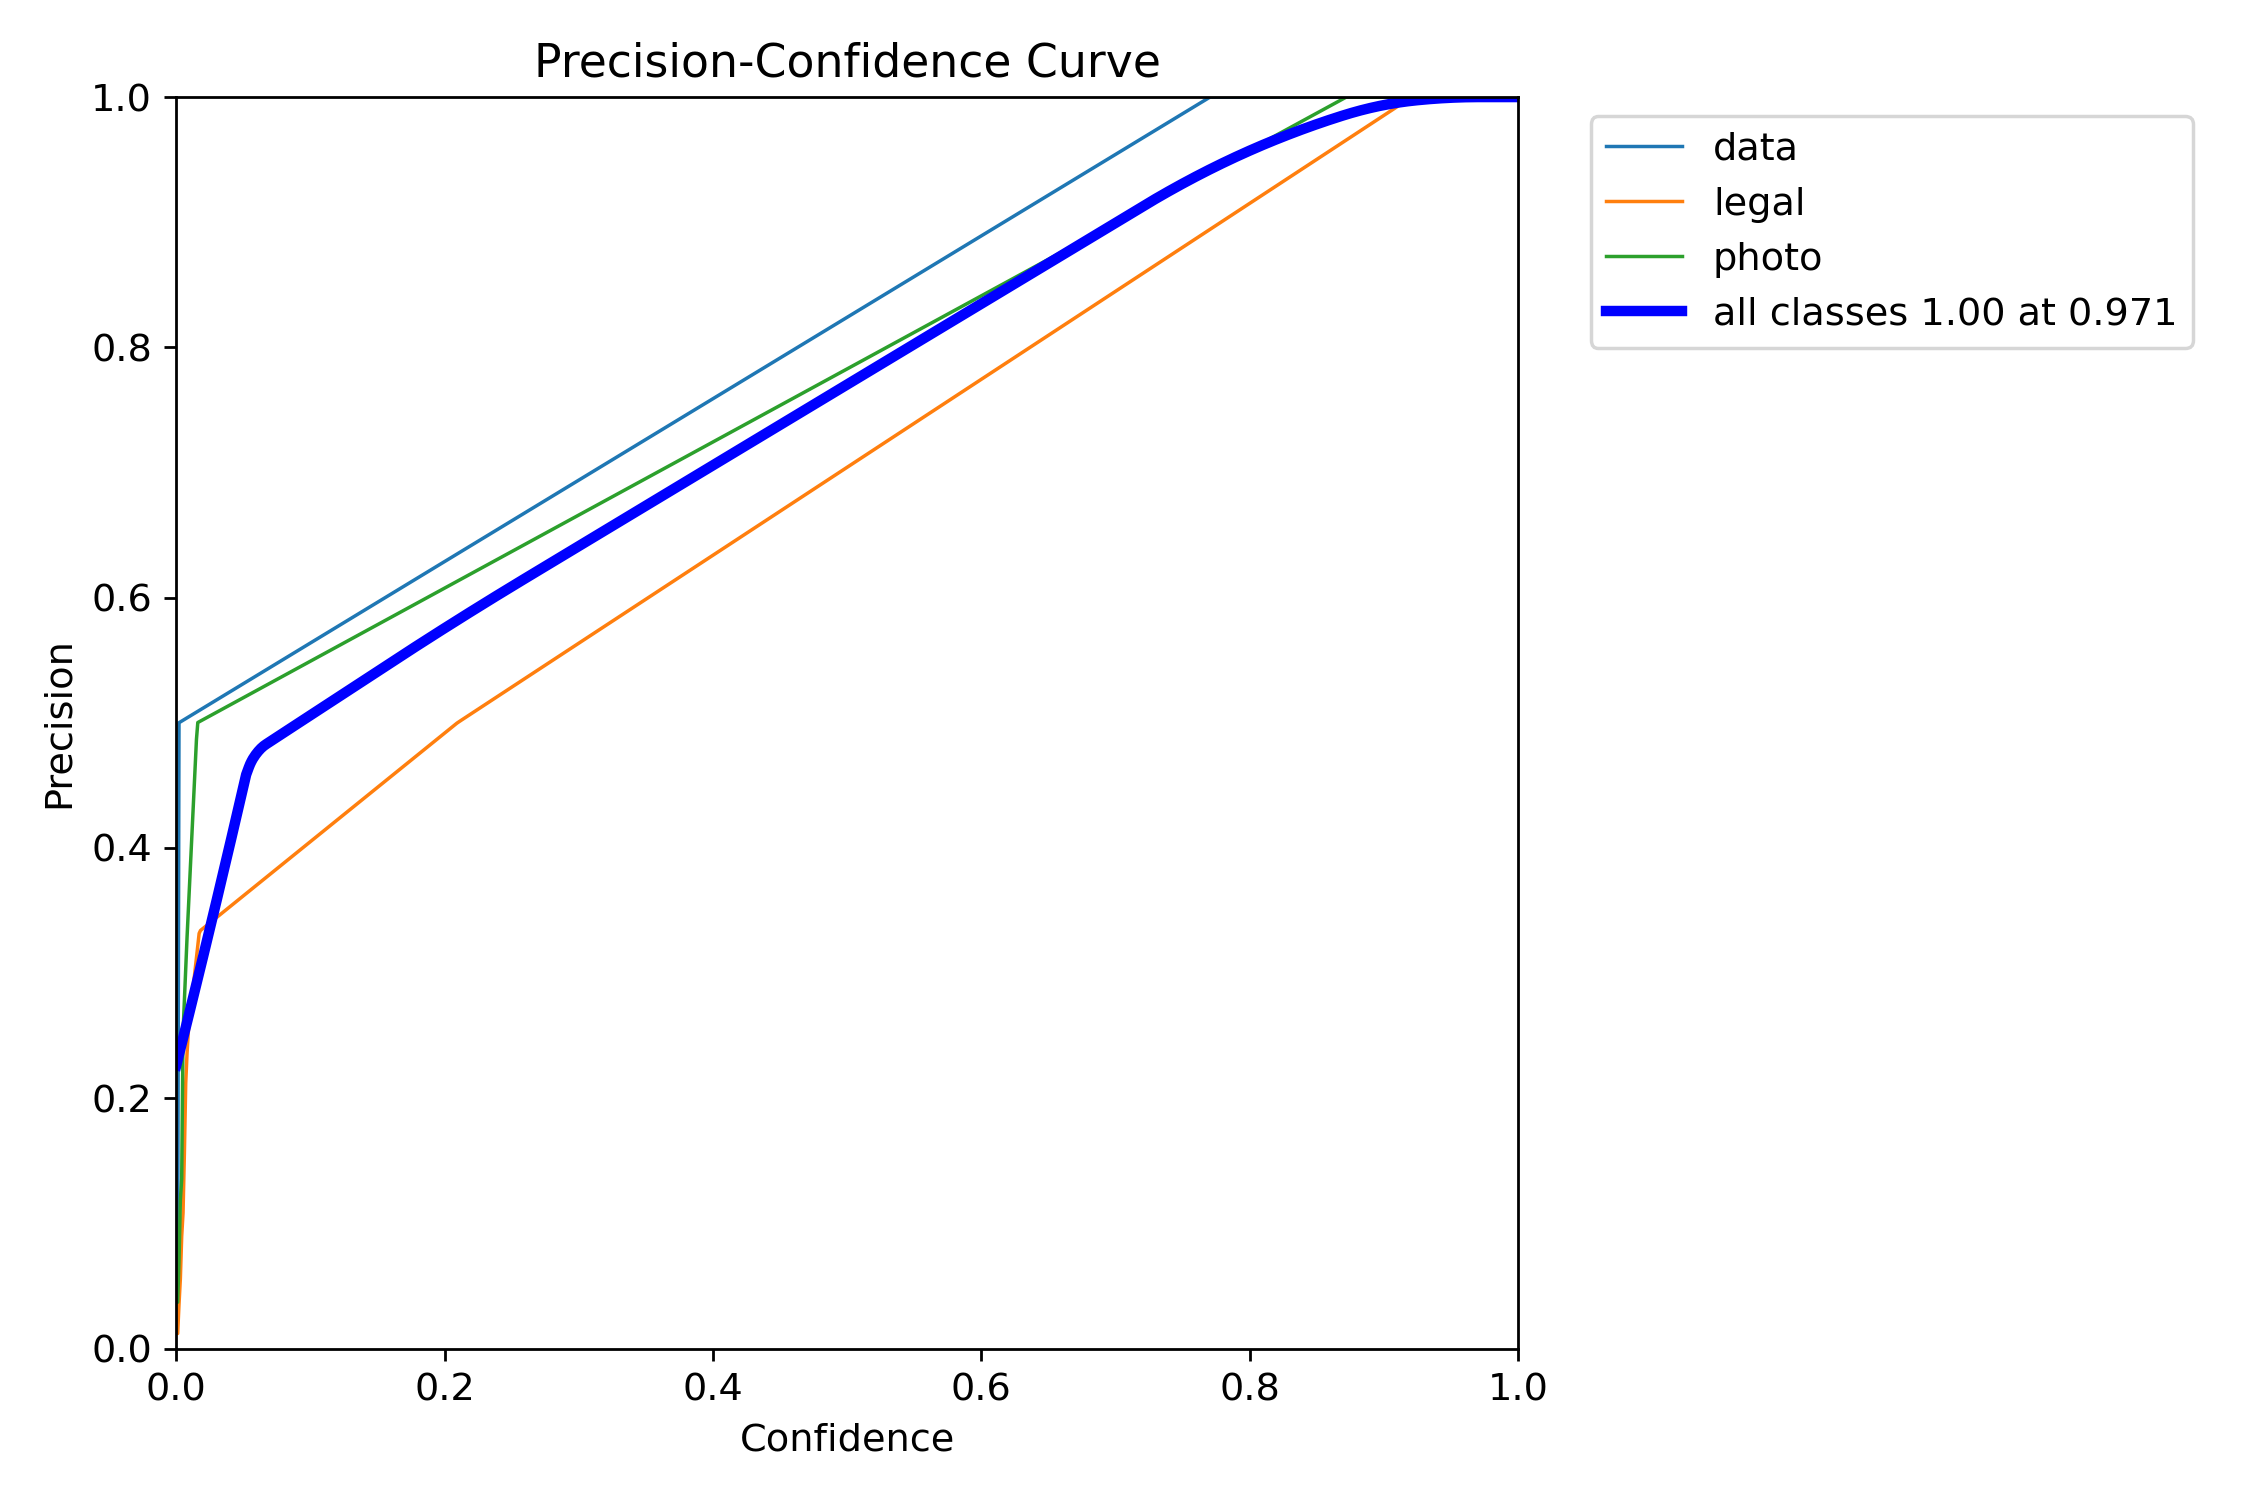


BoxR_curve.png


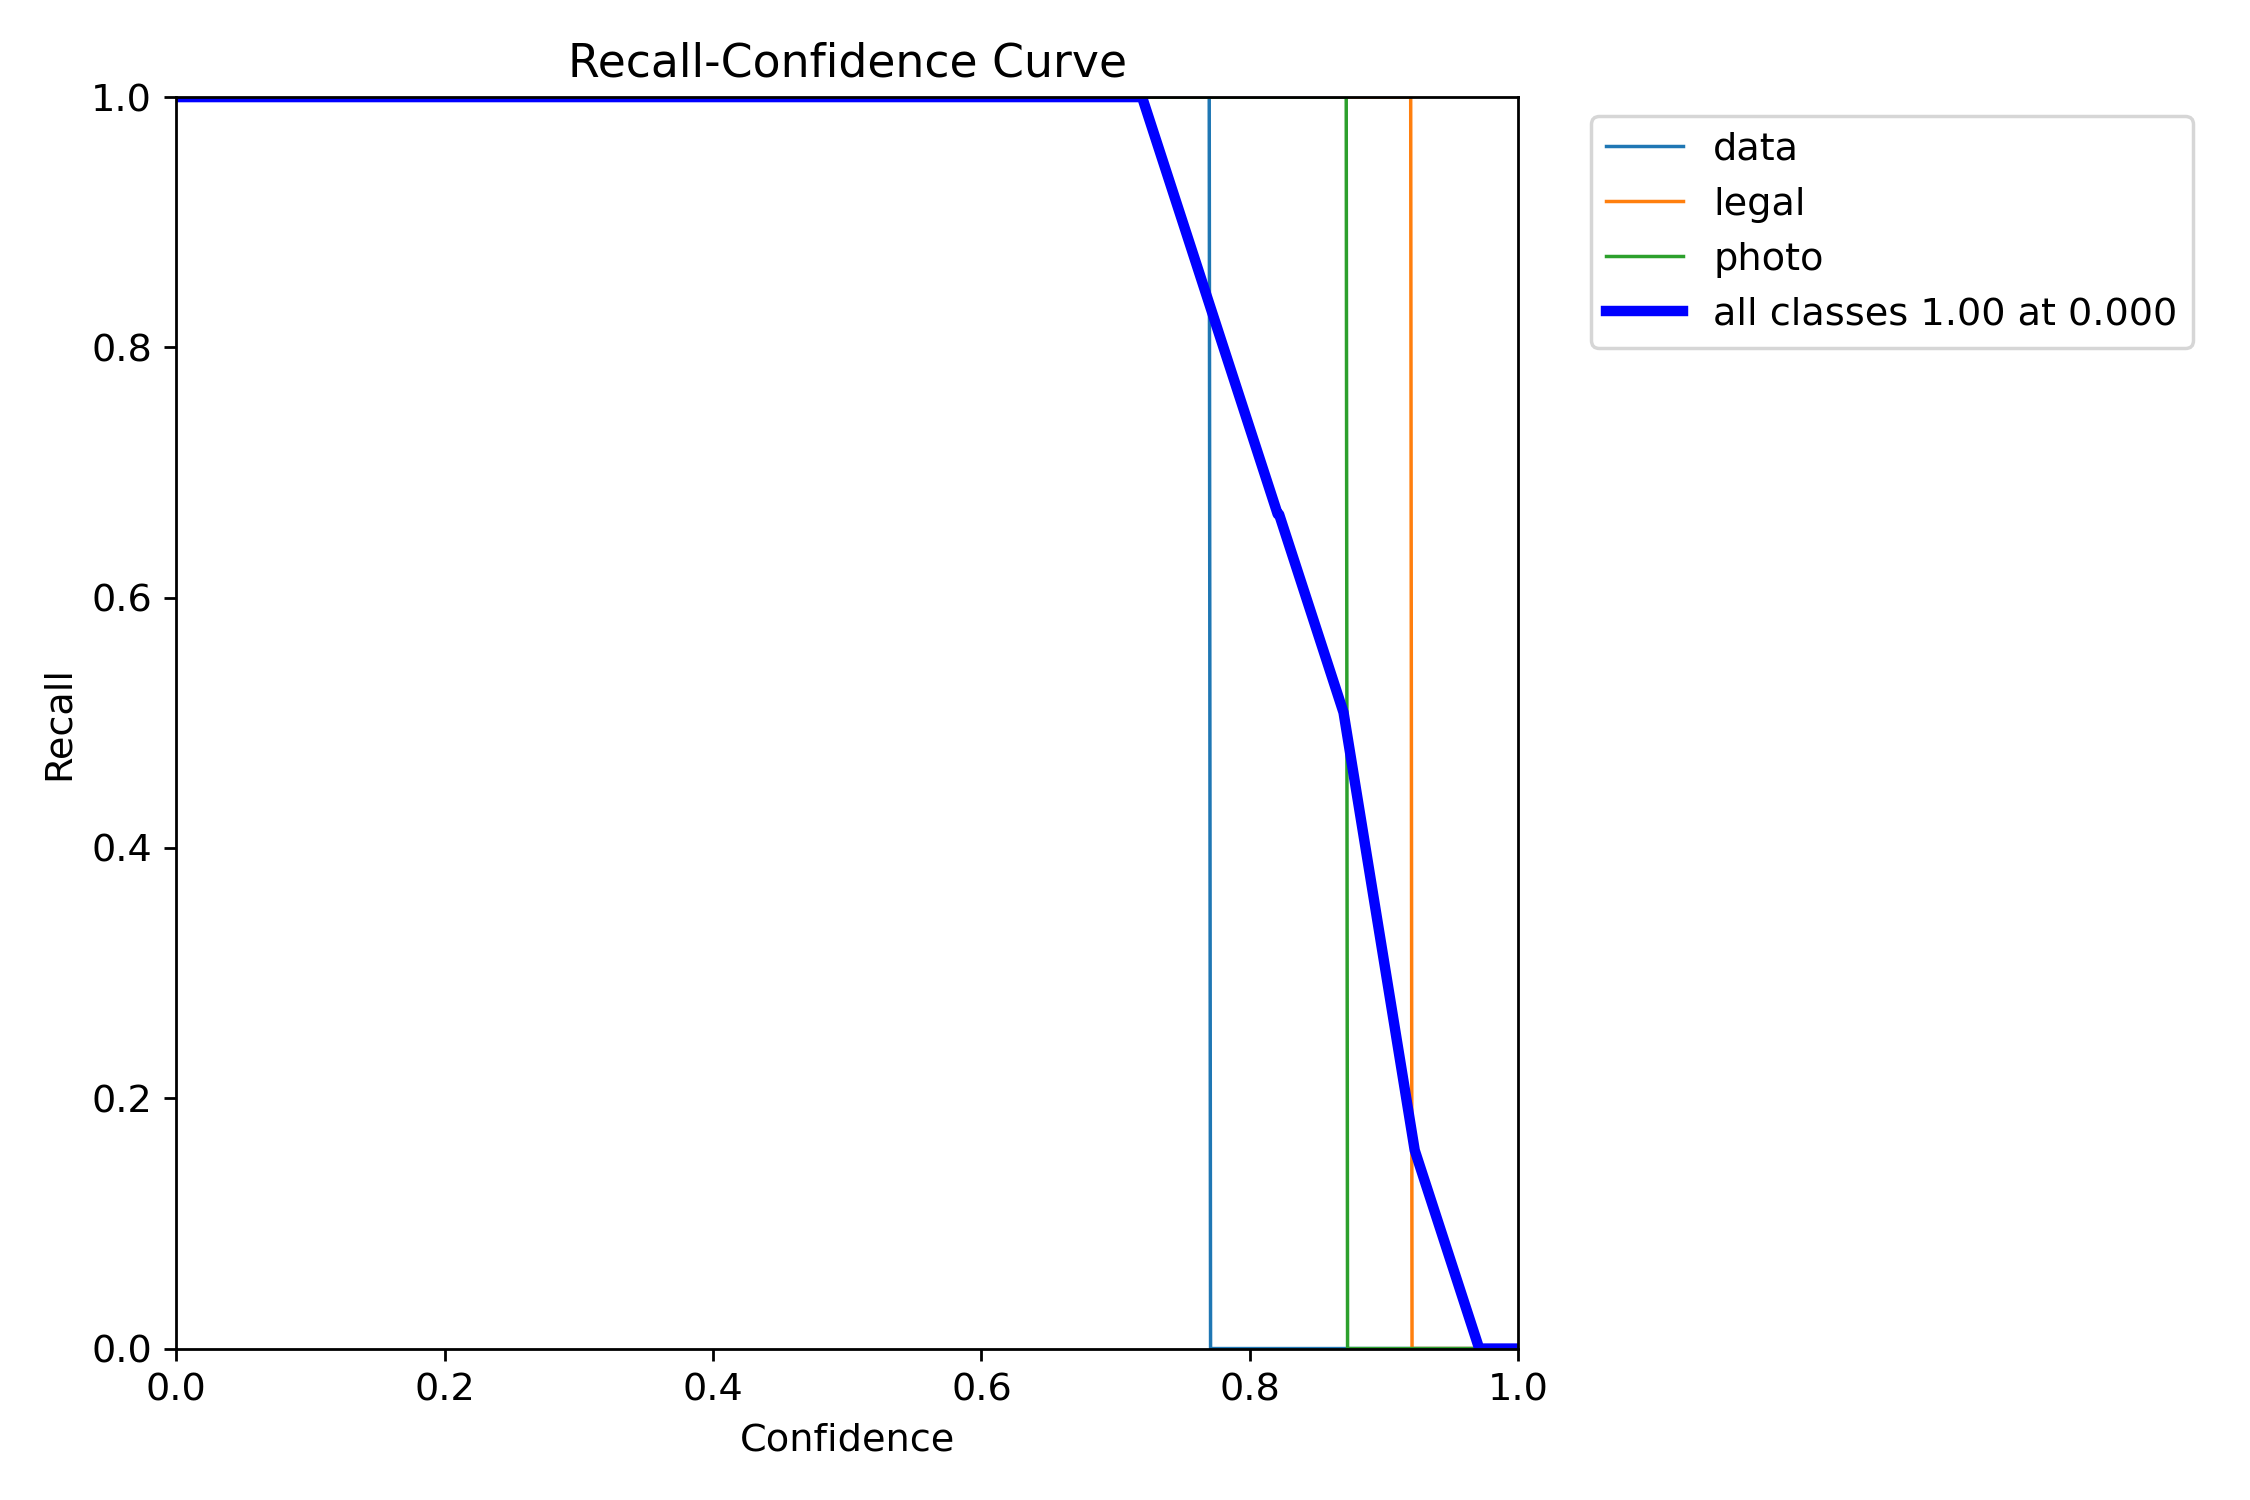


BoxPR_curve.png


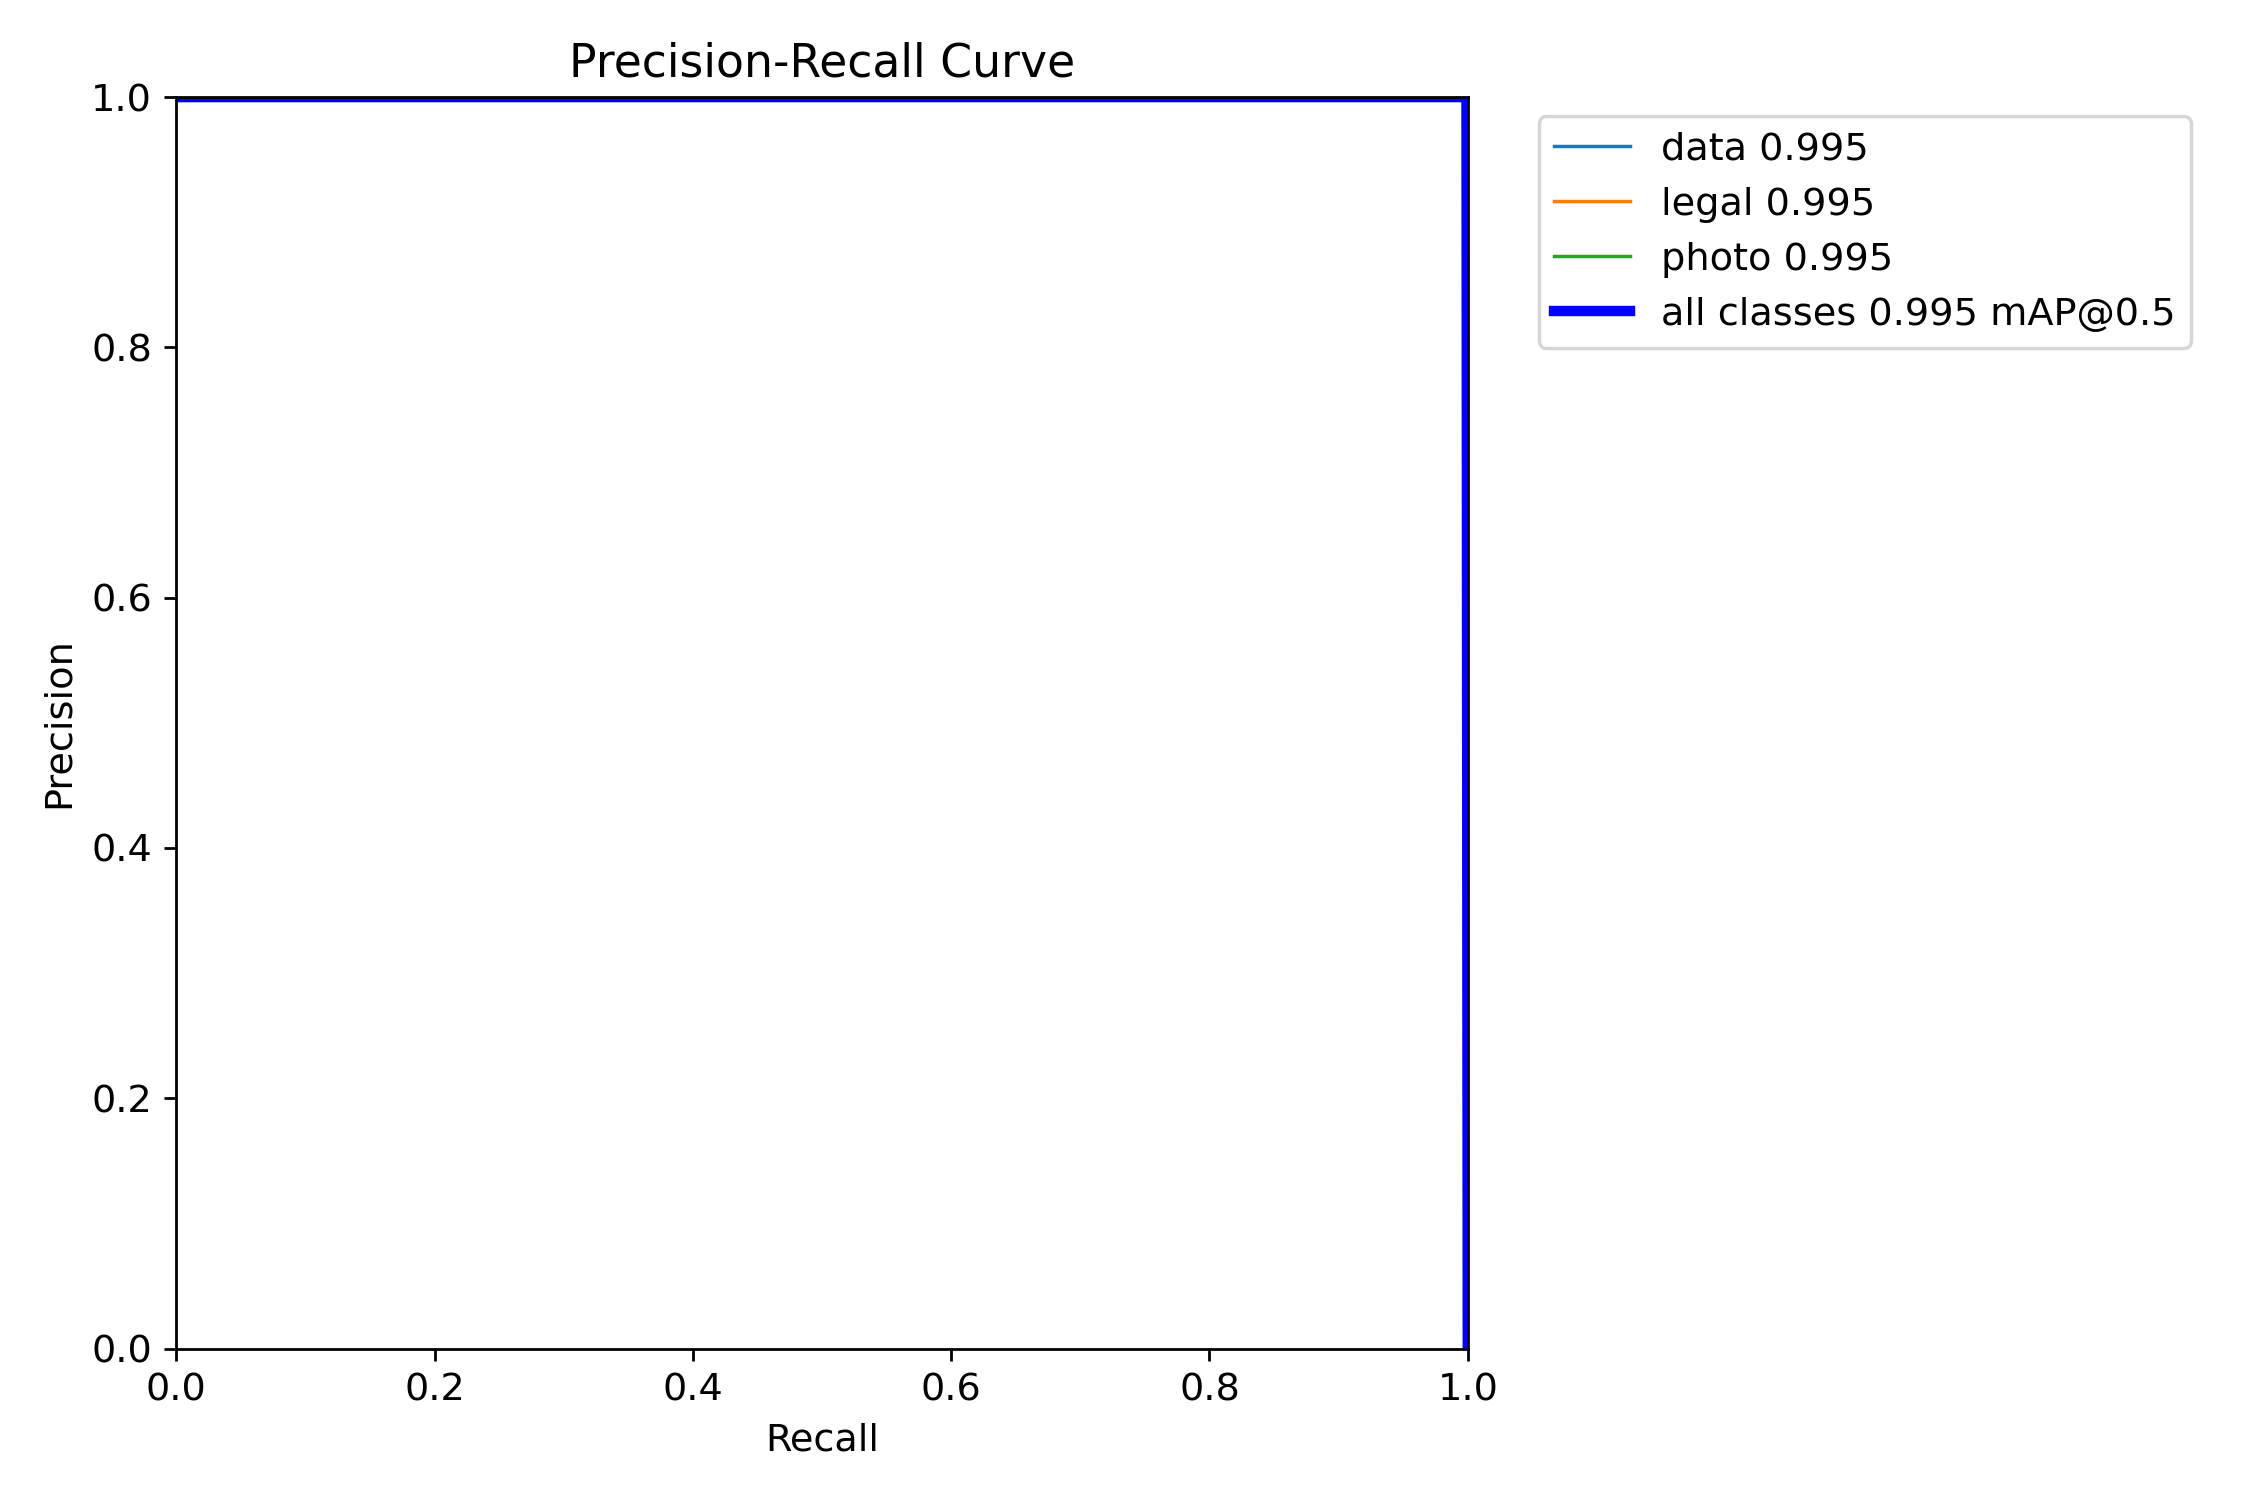


confusion_matrix.png


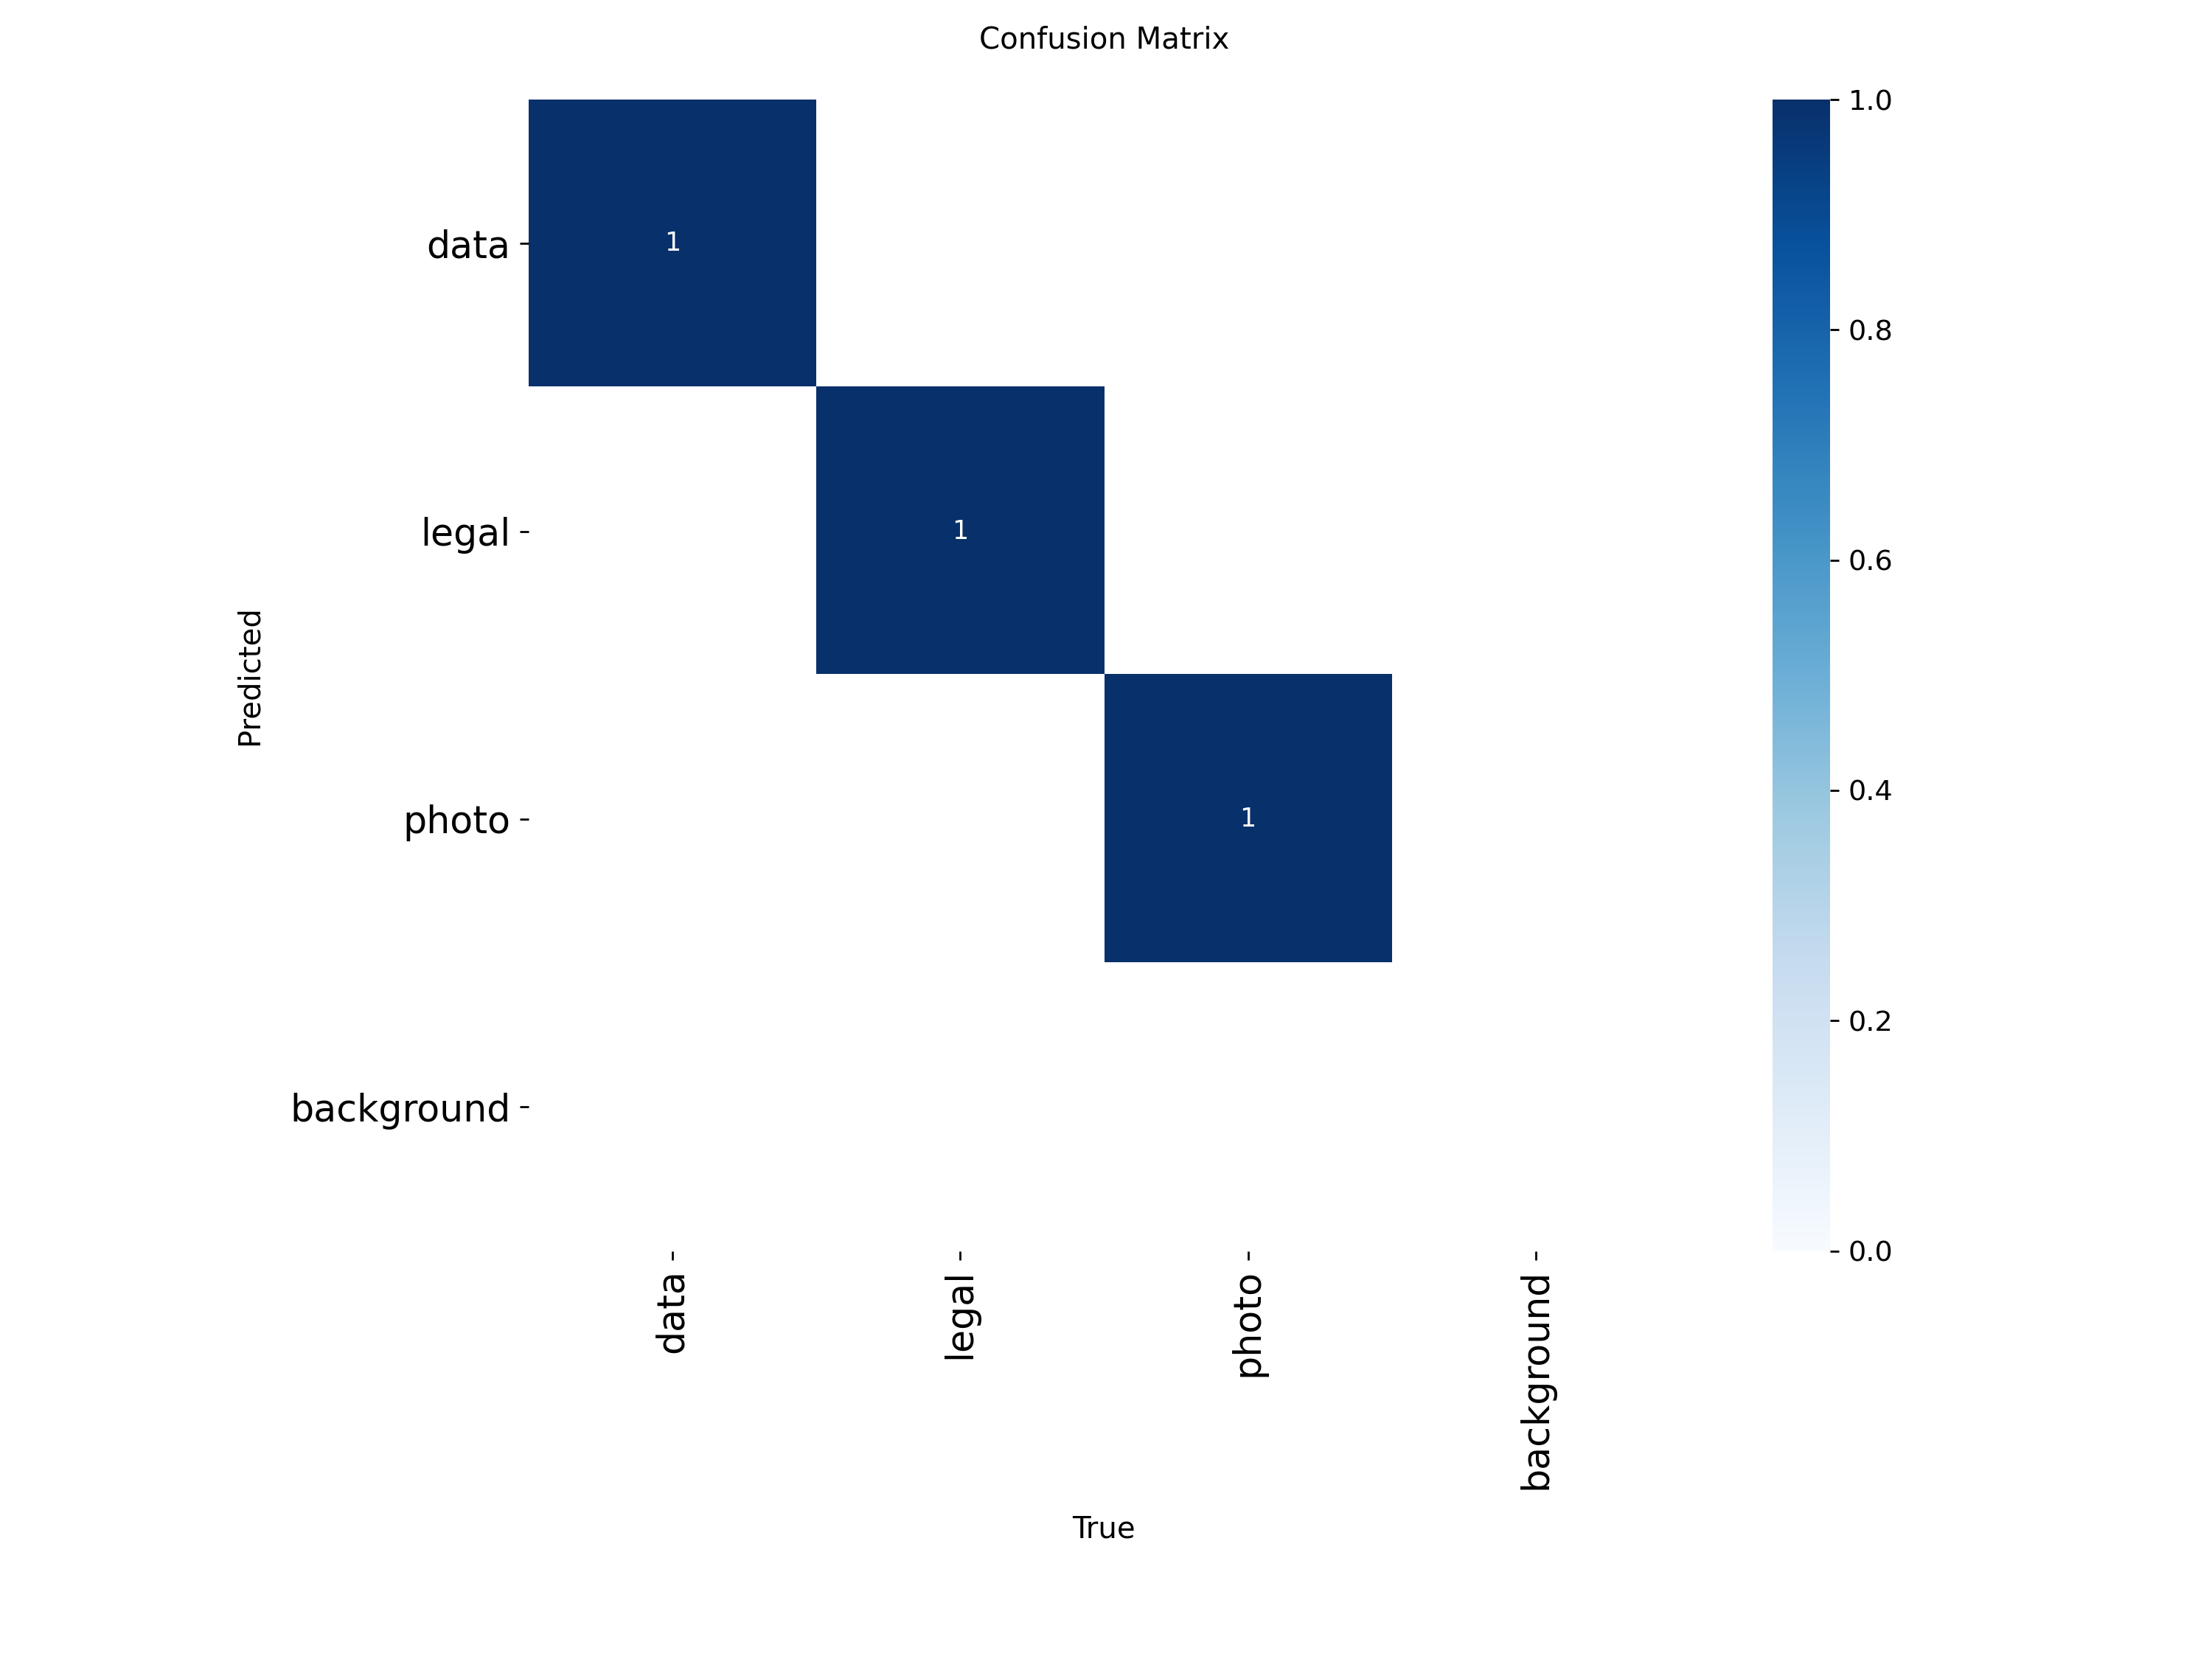


confusion_matrix_normalized.png


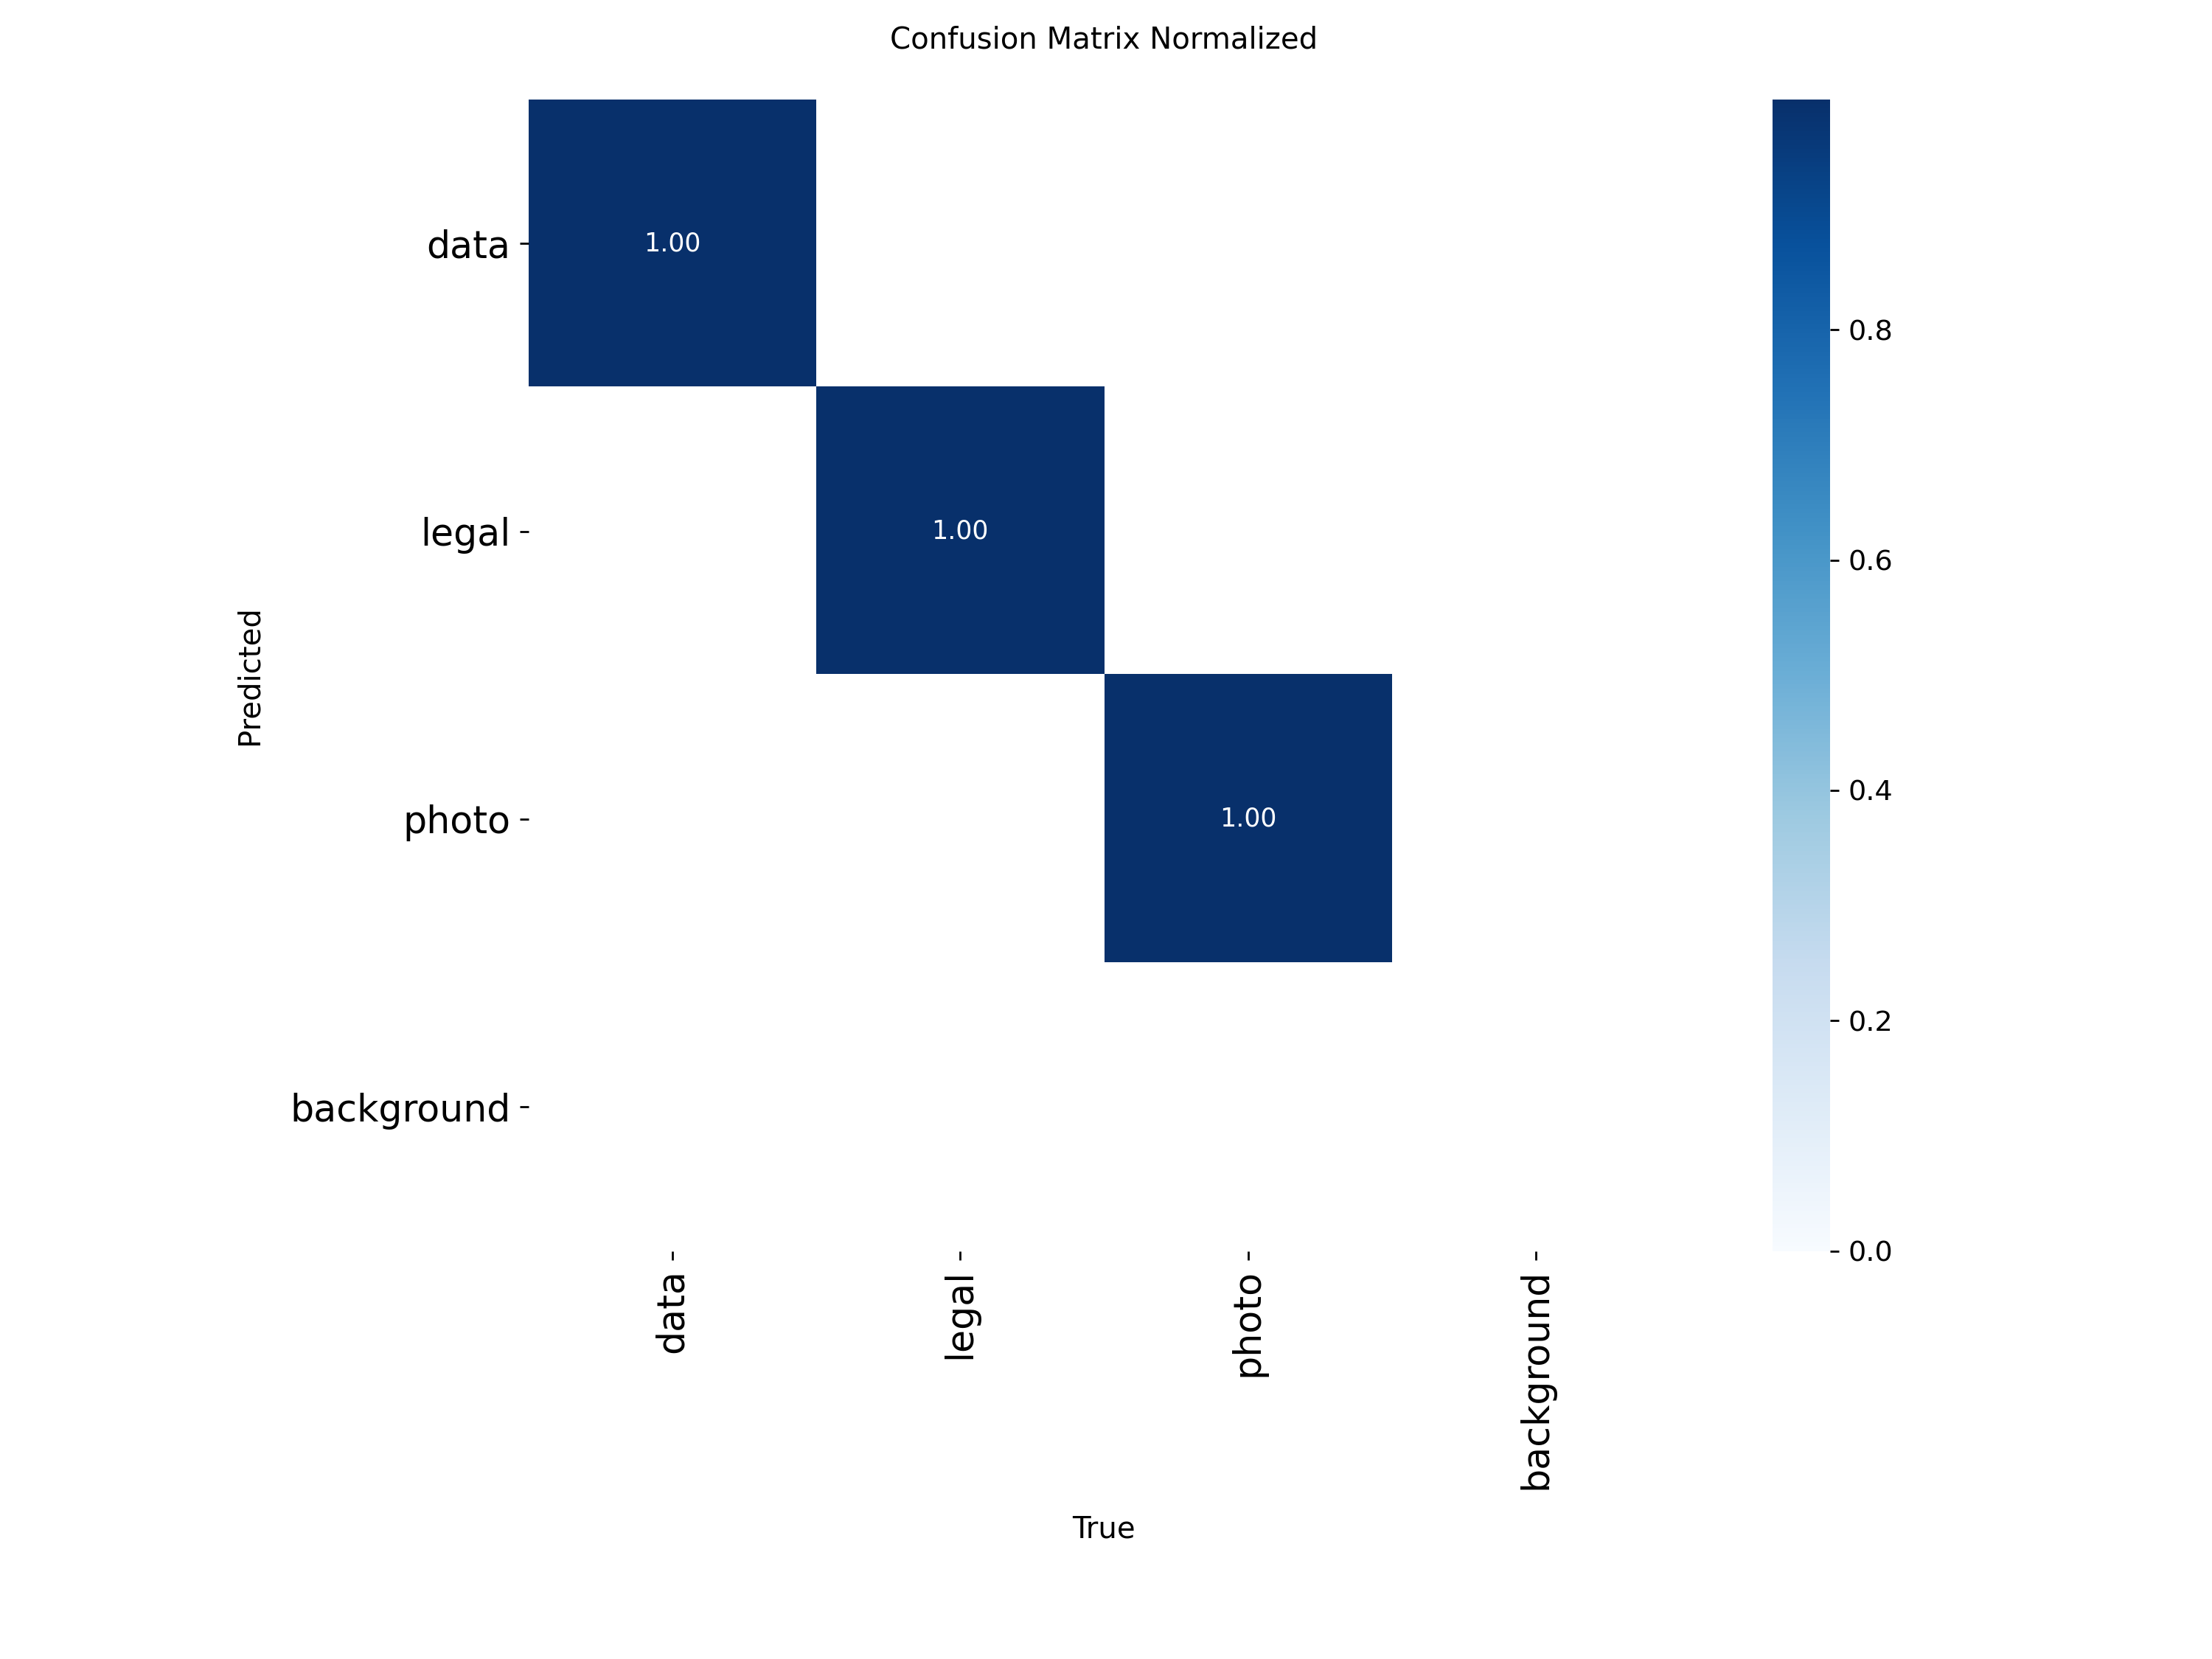

In [ ]:
from IPython.display import display, Image
import os

train_dir = "/content/runs/detect/train"

plots = [
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxPR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]

for plot in plots:
    path = os.path.join(train_dir, plot)
    if os.path.exists(path):
        print(f"\n{plot}")
        display(Image(filename=path, width=700))
    else:
        print(f"{plot} not found.")